In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor,export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [4]:
np.random.seed(42)
x=np.sort(5 * np.random.rand(100,1),axis=0)
y=np.sin(x).ravel()+np.random.normal(0,0.1,x.shape[0])
print(y)

[ 0.03631178  0.07284012  0.13592982 -0.02766026  0.20224683  0.26588096
  0.43414221  0.26064263  0.23870388  0.31164787  0.45572117  0.46104124
  0.41620271  0.56499704  0.55718394  0.6598314   0.50281884  0.60951383
  0.60853441  0.55690845  0.7329577   0.77911291  0.78947765  0.77033558
  0.65664551  0.78838511  0.80371261  0.76036086  0.85705457  1.00231359
  1.16579698  1.00369093  1.01918985  0.98650348  0.80689379  0.99620987
  1.00589686  1.24624929  0.97924517  1.02859523  0.99302854  0.86053961
  1.08984419  1.04132239  1.0338752   0.84044885  0.98384451  0.69135109
  0.86673316  0.97769835  0.60459397  0.56640353  0.62758133  0.48963842
  0.36014357  0.51060126  0.38874848  0.46251339  0.30486974  0.48395778
  0.10023179  0.11930091  0.22910896  0.01251215  0.12642772  0.21294948
 -0.13564894 -0.02771489 -0.14419806 -0.19776246 -0.50637387 -0.52033102
 -0.35979068 -0.4527459  -0.46001636 -0.46082624 -0.68296038 -0.63106452
 -0.62612823 -0.7305425  -0.4833206  -0.65893745 -0

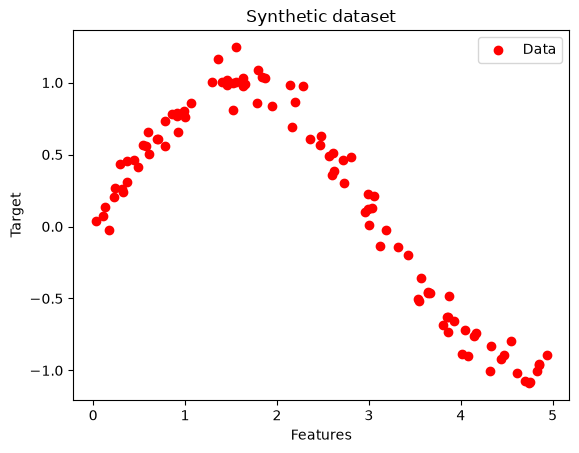

In [5]:
plt.scatter(x,y,color='red',label='Data')
plt.title("Synthetic dataset")
plt.xlabel("Features")
plt.ylabel("Target")
plt.legend()
plt.show()

In [6]:
x_train,x_test,y_train,y_test= train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=42
)

In [25]:
regressor = DecisionTreeRegressor(max_depth=4,random_state=42)

In [26]:
regressor.fit(x_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [27]:
y_pred=regressor.predict(x_test)
mse=mean_squared_error(y_test,y_pred)
print(f"Mean square error : {mse:.4f}")

Mean square error : 0.0151


In [19]:
X_grid = np.arange(min(x), max(x), 0.01)[:, np.newaxis]
y_grid_pred = regressor.predict(X_grid)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='red', label='Data')
plt.plot(X_grid, y_grid_pred, color='blue', label='Model Prediction')
plt.title("Decision Tree Regression")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()

TypeError: only 0-dimensional arrays can be converted to Python scalars

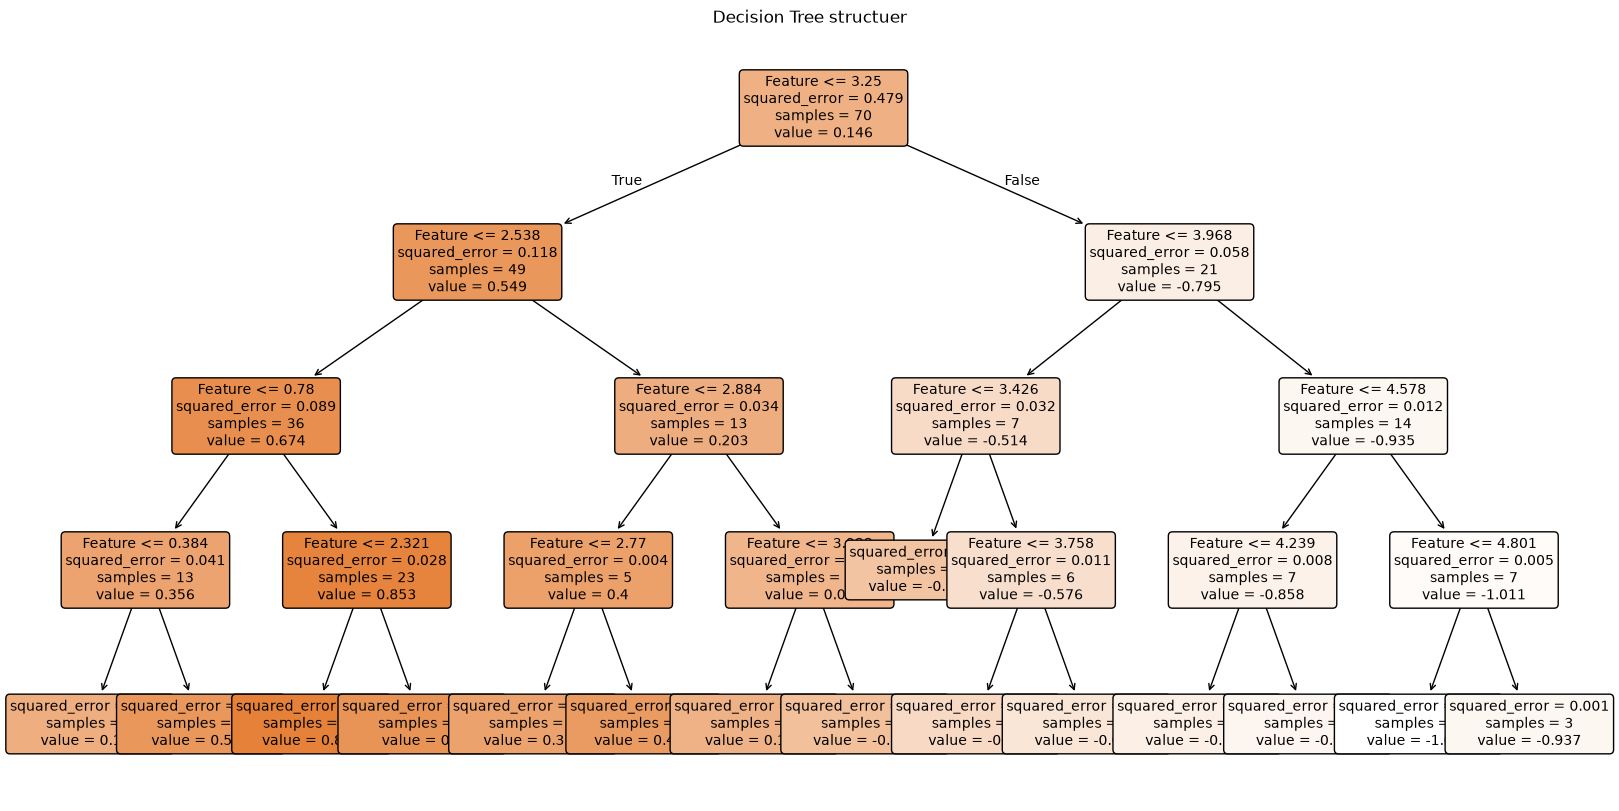

In [28]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(
    regressor,
    feature_names=['Feature'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree structuer")
plt.show()